In [4]:
from random_measurement import generate_povm_set_case_1,generate_povm_set_case_2
from blended_measurement import blended_measurement
# from qiskit.extensions import *
from qiskit.circuit.add_control import add_control
from qiskit.visualization import plot_histogram
from qiskit import  Aer,transpile, QuantumRegister, ClassicalRegister, QuantumCircuit, execute, BasicAer
import numpy as np
import matplotlib.pyplot as plt
import sys
from scipy.linalg import sqrtm
from scipy.linalg import svd
from qiskit.circuit.library import UnitaryGate

print(sys.executable)

import qiskit.tools.jupyter
%qiskit_version_table


/bin/python3


In [5]:
from numpy.linalg import svd
from qiskit.visualization import plot_histogram

def check_for_rank_one(povm):
    """
    function to check if a povm is a rank-1 povm
    """
    rank_one = True
    for p in povm:
        if np.linalg.matrix_rank(p)!=1:
            rank_one = False
            return rank_one
        else:
            continue
    return rank_one
            
# %%
def compute_rank_one_unitary(povm, atol=1e-13, rtol=0):
    """
    This function computes the unitary that rotates the system to the Hilbert space of the ancilla
    Input:  POVM ---> a list of the elements of POVM
    Output: Unitary matrix
    """
           
    # check if povm is a rank-1 povm:
    assert check_for_rank_one(povm), "This is not a rank-1 povm"
    new_povm = []
    for p in povm:
        if np.log2(len(povm))%2==0: #still under investigation
            w, v = np.linalg.eig(p)
        else: 
            w, v = np.linalg.eigh(p) #note the that the eigenvenvector is computer for hermitian eigh
        for eigenvalue, engenvector in zip(w,v):
            if np.isclose(np.abs(eigenvalue), 0):
                continue
            else:
                new_p = np.sqrt(eigenvalue)*engenvector
                new_povm.append(new_p)
    v = np.vstack(new_povm) # arrange the povm elements to form a matrix of dimension: Row X Col*len(povm)
    v = np.atleast_2d(v.T) # convert to 2d matrix
    
    u, s, vh = svd(v)    # apply svd
    tol = max(atol, rtol * s[0])
    nnz = (s >= tol).sum()
    ns = vh[nnz:]         # missing rows of v
    
    # add the missing rows of v to v
    V = np.vstack((v, ns)) 
    
    
    # make the unitary a square matrix of dimension N=2^n where n = int(np.ceil(np.log(V.shape[0])))
    n = int(np.ceil(np.log2(V.shape[0])))
    N = 2**n      # dimension of system and ancilla Hilber space
    r,c = V.shape  
    
    U = np.eye(N, dtype=complex) # initialize Unitary matrix to the identity. Ensure it is complex
    U[:r,:c] = V[:r,:c] # assign all the elements of V to the corresponding elements of U
    
    U = U.conj().T  # Transpose the unitary so that the rows are the povm
    
    # check for unitarity of U
    assert np.allclose(U.T.conj()@U, np.eye(N),atol=1e-13), "Failed to construct U"
    
    return U
    
# %%
# Using the original unitary generator

def compute_full_rank_unitary(povm, atol=1e-13, rtol=0):
    """
    This function computes the unitary that rotates the system to the Hilbert space of the ancilla
    Input:  POVM ---> a list of the elements of POVM
    Output: Unitary matrix
    """
    
         
    # Here square root of the POVM elements were used as a replacement for the vector that form the povm
    povm = [sqrtm(M)for M in povm]
   
    v = np.hstack(povm) # arrange the povm elements to form a matrix of dimension: Row X Col*len(povm)
    v = np.atleast_2d(v) # convert to 2d matrix
    v=v.astype('complex128')
    u, s, vh = svd(v)    # apply svd
    tol = max(atol, rtol * s[0])
    nnz = (s >= tol).sum()
    ns = vh[nnz:]         # missing rows of v
    
    # add the missing rows of v to v
    V = np.vstack((v, ns)) 
    
    
    # make the unitary a square matrix of dimension N=2^n where n = int(np.ceil(np.log(V.shape[0])))
    n = int(np.ceil(np.log2(V.shape[0])))
    N = 2**n      # dimension of system and ancilla Hilber space
    r,c = V.shape  
    
    U = np.eye(N, dtype=complex) # initialize Unitary matrix to the identity. Ensure it is complex
    U[:r,:c] = V[:r,:c] # assign all the elements of V to the corresponding elements of U
    
    U = U.conj().T  # Transpose the unitary so that the rows are the povm
    
    # check for unitarity of U
    assert np.allclose(U.T.conj()@U, np.eye(N),atol=1e-07), "Failed to construct U"
    
    return U

# %%
def rank_one_circuit(povm, state, U):
    
    # Define the quantum and classical registers
    dim_system = state.shape[1] # dimension of state
    num_system_qubit = int(np.ceil(np.log2(dim_system))) # total number of qubits for system

    system_reg = QuantumRegister(num_system_qubit, name='system') # system register

    N = U.shape[0] # Dimension of the unitary to be applied to system and ancilla

    num_ancilla_qubit = int(np.ceil(np.log2(N))) - num_system_qubit # total number of qubits for system

    ancilla_reg = QuantumRegister(num_ancilla_qubit, name='ancilla') # ancilla register

    U_gate = UnitaryGate(U, label='U') # unitary gate to be applied between system and ancilla
    
    
    # create the quantum circuit for the system and ancilla
    qc = QuantumCircuit(system_reg, ancilla_reg, name='circuit')
    qc.initialize(state[0],system_reg)

    # reset ancilla to zero
    qc.reset(ancilla_reg)

    # append the unitary gate
    qc.append(U_gate, range(system_reg.size + ancilla_reg.size))

    # measure only the ancilliary qubits
    qc.measure_all()
    
    return qc

# %%
def full_rank_circuit(povm, state, U):
    
    # Define the quantum and classical registers
    dim_system = state.shape[1] # dimension of state
    num_system_qubit = int(np.ceil(np.log2(dim_system))) # total number of qubits for system

    system_reg = QuantumRegister(num_system_qubit, name='system') # system register

    N = U.shape[0] # Dimension of the unitary to be applied to system and ancilla

    num_ancilla_qubit = int(np.ceil(np.log2(N))) - num_system_qubit # total number of qubits for system

    ancilla_reg = QuantumRegister(num_ancilla_qubit, name='ancilla') # ancilla register

    classical_reg = ClassicalRegister(num_ancilla_qubit, name='measure') # classical register

    U_gate = UnitaryGate(U, label='U') # unitary gate to be applied between system and ancilla
    
    
    # create the quantum circuit for the system and ancilla
    qc = QuantumCircuit(system_reg, ancilla_reg, classical_reg, name='circuit')
    qc.initialize(state[0],system_reg)

    # reset ancilla to zero
    qc.reset(ancilla_reg)

    # append the unitary gate
    qc.append(U_gate, range(system_reg.size + ancilla_reg.size))

    # measure only the ancilliary qubits
    qc.measure(ancilla_reg, classical_reg)
    
    return qc

# %%
def construct_quantum_circuit(povm, state):
    
    # compute unitary matrix
    if check_for_rank_one(povm):
        U = compute_rank_one_unitary(povm)
        qc = rank_one_circuit(povm, state, U)
    else:
        U = compute_full_rank_unitary(povm)
        qc = full_rank_circuit(povm, state, U)
    
    return qc

# %%
def draw_circuit(qc, idle_wires=True):
    """
    This functions draws the naimark extension quantum circuit
    """
    
    return qc.draw(output='mpl', idle_wires=idle_wires)

def naimark_plot(povm, state, counts, names, save=False, file_name="povm_output.pdf"):  
    theory_count = theoretical_probs(povm, state)
    count_list = [theory_count]
    #legend_list = ["Theoretical result"]
    legend_list = ['Theory (t)']
        
    for count, name in zip(counts, names):
        count_list.append(count)
        legend_list.append(name)
    
    fig = plot_histogram(count_list, legend=legend_list, bar_labels=True)
    ax = fig.axes[0]
    title = f"Tetrad POVM with Naimark's extension approach"
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Probabilities', fontsize=12)
    ax.set_xlabel('POVM elements', fontsize=12)
    
    x_lables = []
    for i in range(len(povm)):
        x_lables.append("M"+str(i))
    ax.set_xticks(range(len(povm)))
    ax.set_xticklabels(x_lables)
    
    ax.legend(fontsize=12)
    fig.tight_layout()
    
    if save:
        fig.savefig(file_name)
        
        
    return fig

[0.00246463 0.10558947]
[0.13415863 0.17502394]
[0.0057141  0.07073798]
[0.03060845 0.16527419]
[0.04784873 0.19125509]
[0.02206587 0.03458093]
[0.05059375 0.18639551]
[0.11975336 0.13742277]
[0.01236714 0.07905808]
[0.17062422 0.18461911]
[0.16839949 0.18862698]
[0.00506055 0.16825694]
[0.16647549 0.19164716]
[0.03124457 0.05654477]
[0.81422871 0.90978258]


/home/jason/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/jason/.local/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


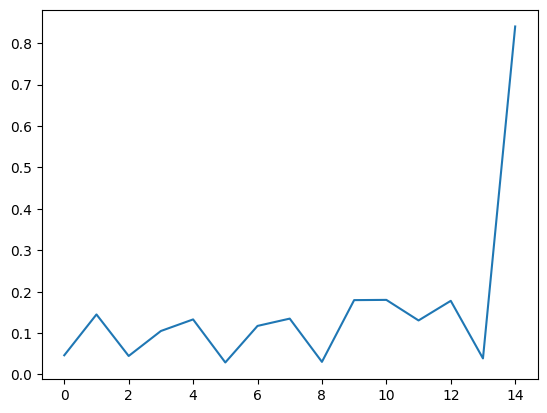

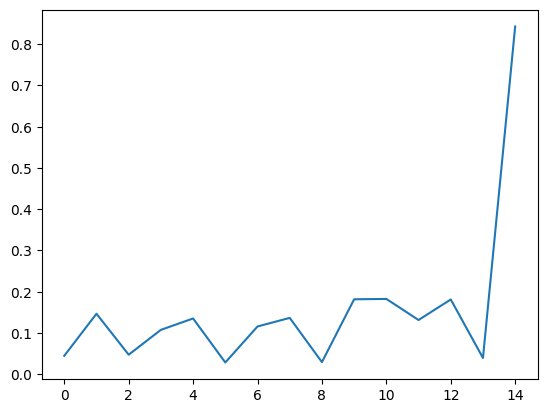

/home/jason/.local/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


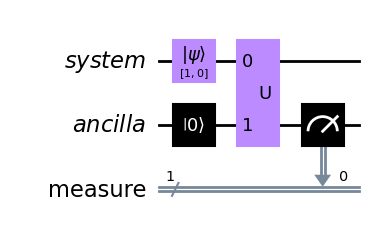

In [6]:

d = 2  # Dimension
m = 15 # Number of POVM elements

################### generate the povm measurement sets ##################################


povm_set_case_1 = generate_povm_set_case_1(d, m)
povm_set_case_2 = generate_povm_set_case_2(d, m)


################### show the povm set #################################################
povm_set_case=povm_set_case_1
pro=[]
# for item in povm_set_case:
#     eigenval,_=np.linalg.eigh(item)
#     print(eigenval)
roh_0=np.array([[1,0],[0,0]])
for item in povm_set_case:
    pro.append(np.trace(item@roh_0))
    
plt.plot(range(0,m),pro)
plt.show()
################## generate blended measurement sets #############################################

# blended_case_1=blended_measurement(povm_set_case_1,d,m)
# blended_case_2=blended_measurement(povm_set_case_2,d,m)

################# construct the quantum circuit #################################################

#initial state
num_shot=16384
state=np.array([[1,0]])
state = state/np.linalg.norm(state)
result_y=[]
for item in povm_set_case:
    povm=[]
    povm.append(item)
    inverse=np.eye(d)-item
    povm.append(inverse)
    qc=construct_quantum_circuit(povm,state)

    backend = BasicAer.get_backend('qasm_simulator')
    result = execute(qc, backend, shots=num_shot).result()
    counts = result.get_counts(qc)
    result_y.append(counts['0'])

# print(counts)
result_y=[item/num_shot for item in result_y]
plt.plot(range(0,m),result_y)
plt.show()
qc.draw('mpl') #always be put at the final line
